## Contexto 

En los últimos años se ha observado un aumento en las readmisiones hospitalarias de pacientes diabéticos en más de 130 hospitales de Estados Unidos. Estas readmisiones generan una mayor sobrecarga operativa y administrativa, impactan negativamente la calidad de la atención y afectan la salud del paciente y su entorno familiar. Ante este escenario, se requiere un análisis basado en datos que permita identificar patrones asociados a la readmisión temprana y evaluar oportunidades de mejora en los procesos de atención y seguimiento.

## Objetivo

Identificar características y patrones asociados a la readmisión hospitalaria dentro de los primeros 30 días posteriores al egreso en pacientes diabéticos, utilizando datos históricos entre 1999 y 2008, con el fin de apoyar la optimización de estrategias de seguimiento y prevención de reingresos.

In [48]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [24]:
diabetic = pd.read_csv("diabetic_data.csv")

In [25]:
diabetic.shape

(101766, 50)

In [26]:
diabetic.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [27]:
diabetic.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [28]:
diabetic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

El conjunto de datos contiene 101.766 registros y 50 variables. De acuerdo con la inspección inicial mediante DataFrame.info(), se identifican 13 variables de tipo numérico (int64) y 37 variables de tipo object.No se observan valores nulos (NaN) en ninguna de las columnas ni inconsistencias evidentes en los tipos de datos.

In [29]:
diabetic.nunique().sort_values() #nos ayuda a mostrar si hay valores unicos o cuántos valores distintos reales tiene cada columna.(podria no ser utiles para analizar el data frame)

citoglipton                      1
examide                          1
troglitazone                     2
change                           2
metformin-pioglitazone           2
metformin-rosiglitazone          2
glimepiride-pioglitazone         2
glipizide-metformin              2
acetohexamide                    2
tolbutamide                      2
diabetesMed                      2
A1Cresult                        3
max_glu_serum                    3
readmitted                       3
tolazamide                       3
gender                           3
acarbose                         4
rosiglitazone                    4
pioglitazone                     4
glyburide                        4
glipizide                        4
insulin                          4
glimepiride                      4
glyburide-metformin              4
miglitol                         4
chlorpropamide                   4
metformin                        4
repaglinide                      4
nateglinide         

In [30]:
diabetic[diabetic.duplicated()]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted


In [31]:
(diabetic == "?").sum().sort_values(ascending=False) #  Es para saber si hay algun dato en especifico es nuestro dataframe. En este caso si hay "?" No detecta NaN, "Unknown", "Not Available", Espacios en blanco " "Valores inválidos numéricos (999, -1)

weight                      98569
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
tolazamide                      0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
troglitazone                    0
citoglipton                     0
examide                         0
acetohexamide                   0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glipizide                       0
repaglinide                     0
glimepiride   

El dataset no presenta valores nulos explícitos ni duplicados. Sin embargo, se identifican valores faltantes codificados como “?” en múltiples variables categóricas, especialmente en weight, medical_specialty y payer_code. Para garantizar un análisis estadístico correcto, estos valores "?" se transformaran a NaN, permitiendo su correcta identificación y tratamiento.

In [32]:
diabetic_clean = diabetic.replace("?", np.nan) #Convertir "?" en valores nulos reales (NaN)
diabetic_clean.isnull().mean().sort_values(ascending=False) * 100 # mostrará el % real de datos perdidos por columna.

weight                      96.858479
max_glu_serum               94.746772
A1Cresult                   83.277322
medical_specialty           49.082208
payer_code                  39.557416
race                         2.233555
diag_3                       1.398306
diag_2                       0.351787
diag_1                       0.020636
encounter_id                 0.000000
troglitazone                 0.000000
tolbutamide                  0.000000
pioglitazone                 0.000000
rosiglitazone                0.000000
acarbose                     0.000000
miglitol                     0.000000
citoglipton                  0.000000
tolazamide                   0.000000
examide                      0.000000
glipizide                    0.000000
insulin                      0.000000
glyburide-metformin          0.000000
glipizide-metformin          0.000000
glimepiride-pioglitazone     0.000000
metformin-rosiglitazone      0.000000
metformin-pioglitazone       0.000000
change      

In [33]:
diabetic_clean.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


Se eliminaron las columnas weight, max_glu_serum y A1Cresult debido a que presentan más del 80 % de valores faltantes, lo que impide una imputación confiable y compromete la validez estadística de cualquier análisis derivado. Esto representa una limitación clínica relevante ya que el control glucémico es un factor determinante en pacientes diabéticos. Asimismo, las variables medical_specialty y payer_code fueron excluidas por no aportar información relevante para el objetivo del estudio, el cual se centra en el comportamiento clínico y la evolución del paciente, y no en aspectos administrativos o de facturación. Por ultimo las columnas de medicamentos

Las variables correspondientes a medicamentos administrados durante la hospitalización fueron excluidas debido a su baja frecuencia de uso y a que no contribuyen de forma directa a la resolución de la pregunta de investigación. La inclusión de estas variables incrementa la dimensionalidad del conjunto de datos y la esparsidad de la información, sin aportar valor analítico significativo, lo que podría introducir ruido y afectar la interpretabilidad y el desempeño de los modelos.

In [34]:
diabetic_clean.columns #ver todas las columnas

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [35]:
#Crear una lista las columnas a elimina  y un nuevo dataframe sin los medicamentos. no borrar el dataframe original
medication_columnoas_valores_faltantes = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',         
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', "weight", "medical_specialty", "payer_code", "max_glu_serum", "A1Cresult"]

diabetic_final= diabetic_clean.drop(columns=medication_columnoas_valores_faltantes)

In [36]:
#Validar que todo salio bien
diabetic_final.shape

(101766, 22)

In [37]:
#Validar que todo salio bien
diabetic_final.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,0,0,0,250.83,NaN,NaN,1,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,0,0,0,276,250.01,255,9,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,2,0,1,648,250,V27,6,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,0,0,0,8,250.43,403,7,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,0,0,0,197,157,250,5,Ch,Yes,NO


In [38]:
diabetic_final.columns 

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'change', 'diabetesMed', 'readmitted'],
      dtype='object')

Posterior a la limpieza inicial, se verificó que el dataset mantiene su tamaño muestral original, con reducción controlada del número de variables. Los valores faltantes fueron correctamente identificados y estandarizados, permitiendo continuar con análisis exploratorio sin sesgos derivados de codificaciones erróneas.

Se seleccionaron como variables core (que podrin explicar la readmisión) aquellas directamente relacionadas con la severidad clínica, complejidad del manejo y antecedentes de utilización de servicios de salud, dado su respaldo en la literatura como predictores de readmisión hospitalaria temprana. Las variables diagnósticas (diag_1, diag_2 y diag_3) se conservaron para posterior transformación en categorías clínicas agregadas, con el fin de reducir dimensionalidad y mejorar interpretabilidad. Variables identificadoras como patient_nbr fueron excluidas del análisis explicativo por no aportar información clínica ni operativa relevante.

¿Cuantos < 30 dias hay?

In [39]:
diabetic_final["readmitted"].unique() #para saber los valores unicos en esa columna

array(['NO', '>30', '<30'], dtype=object)

In [40]:
diabetic_final["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

<Axes: xlabel='readmitted'>

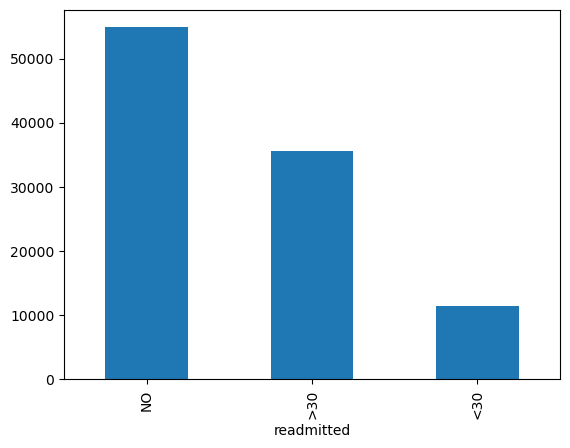

In [47]:
diabetic_final['readmitted'].value_counts().plot(kind='bar')

Hay 11357 registros con readmisión <30 días 
¿Que nos dice esto? En el Dataset tenemos en total 101766 lo que corresponde al 11.5%. Significa que la tasa de readmision <30 días es poco frecuente, es decir que 1 de cada 9 pacientes regresan la area de hospitalizacion en menos de 30 dias

Vamos a resolver preguntas:
1.¿Qué grupos de edad presentan mayor tasa de readmisión en <30 días?

In [41]:
diabetic_final['readmit_less_30'] = diabetic_final['readmitted'] == '<30' #Creamos un columna booleana de readmision < 30 dias
age_group_summary = diabetic_final.groupby('age')['readmit_less_30'].mean().reset_index() #Agrupamos por edad y calculamos la tasa de readmision < 30 dias
age_group_summary['readmit_less_30'] = (age_group_summary['readmit_less_30'] * 100).round(2) #Convertimos la tasa a porcentaje y redondeamos a 2 decimales
age_group_summary = age_group_summary.sort_values(by='readmit_less_30', ascending=False).reset_index(drop=True) #Ordenar de mayor a menor según la tasa de readmisión
(age_group_summary)



,age,readmit_less_30
0,[20-30),14.24
1,[80-90),12.08
2,[70-80),11.77
3,[30-40),11.23
4,[60-70),11.13
5,[90-100),11.10
6,[40-50),10.60
7,[50-60),9.67
8,[10-20),5.79
9,[0-10),1.86


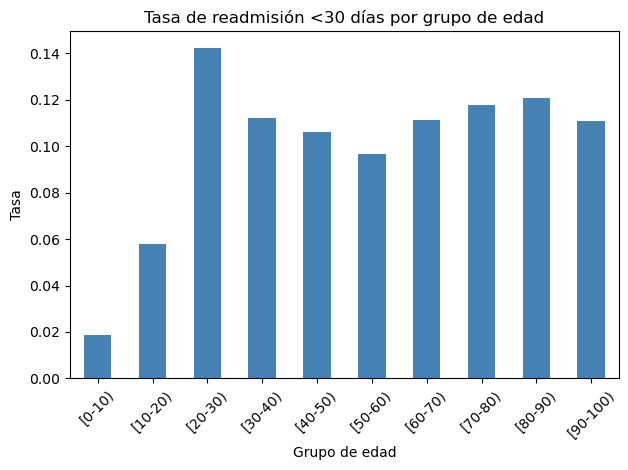

In [50]:
# Definir el orden correcto de edades
orden_edad = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', 
              '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

# Graficar en ese orden
diabetic_final.groupby('age')['readmit_less_30'].mean().reindex(orden_edad).plot(
    kind='bar', color='steelblue')

plt.title('Tasa de readmisión <30 días por grupo de edad')
plt.ylabel('Tasa')
plt.xlabel('Grupo de edad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

los grupos que presentan mayor tasa de readmision son en 1er lugar  pacientes entre 20-30 años en un 14.2%, en un 2do lugar entre 80-90 años con un 12% , en 3er lugar paciente entre 70-80% con un 11.7%, en 4to lugar  pacientes entre 30-40 años con 11.2% y en 5to lugar pacientes entre 60-70 años con 11.1%. Llama la atención que el rango de edad que mas presenta readmisiones son jovenes entre 20-30 años. Lo que hace cuestionarme si son paciente con diabetes tipo i?? No tienen buena adherencia al tratamiento por su edad? que su estilo de vida y factores sociales intervengan??

¿Como puedo profundizar ?
1.Revisando las comorbilidades de base y cruzarlas
2.Analizar tipo de medicamentos que usan estos pacientes
3.Cruzar edad vs readmisión vs medicación --- Nos permite ver si la alta tasa se concentra en jóvenes con ciertos tratamientos.

In [46]:
diabetic_final.groupby('age')['readmit_less_30'].agg(['mean', 'count'])

,mean,count
age,,
[0-10),0.018634,161
[10-20),0.057887,691
[20-30),0.142426,1657
[30-40),0.112318,3775
[40-50),0.106040,9685
[50-60),0.096662,17256
[60-70),0.111284,22483
[70-80),0.117731,26068
[80-90),0.120835,17197


El grupo de 20-30 años presenta la tasa más alta de readmisión con 14.2%, basado en 1,657 pacientes — una muestra suficiente para considerar este hallazgo estadísticamente confiable. Este resultado es contraintuitivo y sugiere explorar factores como tipo de diabetes, adherencia al tratamiento y condiciones sociales en este grupo.

2.¿Existe diferencia de readmisión <30 días según sexo?

In [42]:
sex_summary = diabetic_final.groupby('gender')['readmit_less_30'].mean().reset_index() ## Agrupar por sexo y calcular tasa de readmisión <30 días
sex_summary['readmit_less_30'] = (sex_summary['readmit_less_30'] * 100).round(2) # Convertir a porcentaje y redondear
sex_summary = sex_summary.sort_values(by='readmit_less_30', ascending=False).reset_index(drop=True)
(sex_summary)

,gender,readmit_less_30
0,Female,11.25
1,Male,11.06
2,Unknown/Invalid,0.00


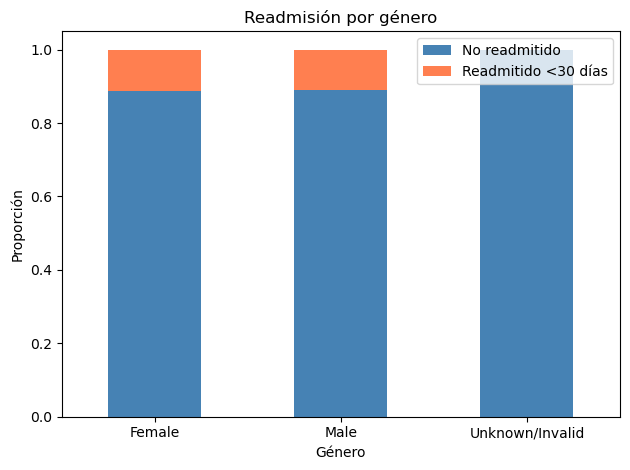

In [58]:
# Renombrar los valores para que sea legible
diabetic_final['readmit_less_30_label'] = diabetic_final['readmit_less_30'].map({
    False: 'No readmitido',
    True: 'Readmitido <30 días'
})

pd.crosstab(diabetic_final['gender'], diabetic_final['readmit_less_30_label'],
    normalize='index').plot(kind='bar', stacked=True,
    color=['steelblue', 'coral'])

plt.title('Readmisión por género')
plt.ylabel('Proporción')
plt.xlabel('Género')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

No hay diferencia signficiativa de readmisiones segun sexo.

3.¿Qué diagnósticos están asociados a readmisión <30 días?

In [43]:
 #filtrar pacientes con readmision <30 dias
readmit_30 = diabetic_final[diabetic_final['readmit_less_30'] == True]
#Contar diagnosticos principales
diag_summary = (          
    readmit_30['diag_1']
    .value_counts()
    .reset_index() 
) 
diag_summary.columns = ['diagnosis', 'count']

#Ver los diagnosticos mas frecuentes
print(diag_summary.head(10))

  diagnosis  count
0       428    968
1       414    595
2       410    373
3       434    329
4       486    314
5       786    291
6       491    287
7       996    264
8       276    257
9       427    252


Los codigos son en base al ICD-9-CM. Los diagnosticos principales en paciente readmitidos <30 dias son dominadas por patologias cardiovascular en 1er lugar, seguida de respiratorias y metabolicas.

4.¿Pacientes con múltiples hospitalizaciones previas tienen mayor riesgo de readmisión <30 días? o ¿Existe una relación positiva entre el número de hospitalizaciones previas y la probabilidad de readmisión temprana?

In [44]:
#Agrupar hospitalizaciones previas
diabetic_final['prior_hosp_group'] = pd.cut(
    diabetic_final['number_inpatient'],
    bins=[-1, 0, 1, 3, diabetic_final['number_inpatient'].max()],
    labels=['0', '1', '2-3', '4+']
)

#calcular tasa de readmisión <30 días por grupo
readmit_by_hosp = (
    diabetic_final
    .groupby('prior_hosp_group')['readmit_less_30']
    .mean()
    .reset_index()
)

readmit_by_hosp['readmit_rate_%'] = readmit_by_hosp['readmit_less_30'] * 100
readmit_by_hosp

/var/folders/22/s6kwmd_d2z15vv7w2pb30sm00000gn/T/ipykernel_1283/1923335522.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('prior_hosp_group')['readmit_less_30']


,prior_hosp_group,readmit_less_30,readmit_rate_%
0,0,0.084371,8.437084
1,1,0.129245,12.924543
2,2-3,0.183201,18.320124
3,4+,0.307037,30.703683


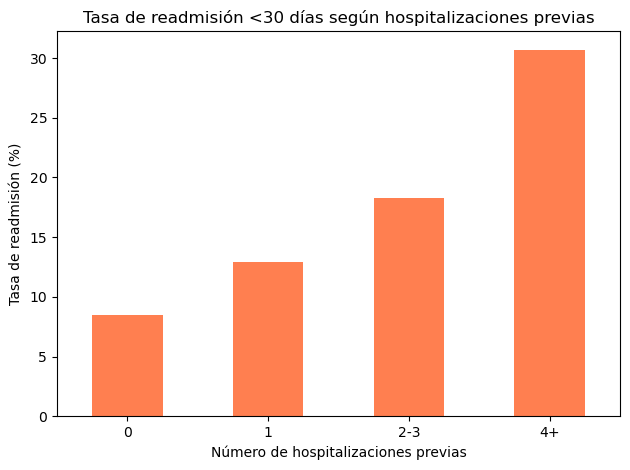

In [65]:
readmit_by_hosp.plot(
    x='prior_hosp_group',
    y='readmit_rate_%',
    kind='bar',
    color='coral',
    legend=False
)

plt.title('Tasa de readmisión <30 días según hospitalizaciones previas')
plt.xlabel('Número de hospitalizaciones previas')
plt.ylabel('Tasa de readmisión (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Se puede observa una relacion directa que a mayor numero de hospitalizaciones previas mayor tasa de readmision < 30 dias. Lo que puede sugerir un predictor de readmision temprana.
Respuesta tecnica: Sí. Se observa un incremento progresivo y significativo en la tasa de readmisión <30 días a medida que aumenta el número de hospitalizaciones previas. Los pacientes con ≥4 hospitalizaciones presentan una tasa de readmisión cercana al 31%, en comparación con 8.4% en pacientes sin hospitalizaciones previas, lo que indica que el historial de hospitalizaciones es un fuerte predictor de readmisión temprana.

## Analisis de asociación

Aquí verificamos las hipotesis
Paso 1: Hipotesis 1: "Los pacientes mayores de 60 años tienen mayor probabilidad de readmisión <30 días que los menores de 60 años."
Paso 2: Necesito comparar DOS grupos — mayores de 60 vs menores de 60.
Paso 3: Me pregunto ¿qué tengo en los datos? Tengo age con rangos como [20-30), [60-70) etc. Tengo readmit_less_30 con 0 y 1.
Paso 4: Me pregunto ¿cómo creo esos dos grupos? Necesito separar las edades en dos categorías: mayor o menor de 60. Eso es una variable binaria nueva.
Paso 5 — Me pregunto ¿cómo comparo los grupos? Calculando la tasa de readmisión de cada grupo. Tasa = promedio de readmit_less_30 por grupo × 100.

In [66]:
# Crear variable binaria mayor/menor de 60
edad_orden = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', 
              '[40-50)', '[50-60)', '[60-70)', '[70-80)', 
              '[80-90)', '[90-100)']

mayores_60 = ['[60-70)', '[70-80)', '[80-90)', '[90-100)']

diabetic_final['mayor_60'] = diabetic_final['age'].isin(mayores_60)

# Comparar tasas
tasas = diabetic_final.groupby('mayor_60')['readmit_less_30'].mean() * 100
print(tasas)




mayor_60
False    10.227239
True     11.612028
Name: readmit_less_30, dtype: float64
